Corrélations fortes (|r| ≥ 0.8) :
🔴 Nationality Group ↔ International : 0.8335
🔴 Curricular units 1st sem (credited) ↔ Curricular units 1st sem (enrolled) : 0.8594
🔴 Curricular units 1st sem (credited) ↔ Curricular units 2nd sem (credited) : 0.9415
🔴 Curricular units 1st sem (enrolled) ↔ Curricular units 2nd sem (credited) : 0.8383
🔴 Curricular units 1st sem (enrolled) ↔ Curricular units 2nd sem (enrolled) : 0.9142
🔴 Curricular units 1st sem (approved) ↔ Curricular units 2nd sem (approved) : 0.8889
🔴 Curricular units 1st sem (grade) ↔ Curricular units 1st sem (Approved/Enrolled) : 0.8400
🔴 Curricular units 1st sem (grade) ↔ Curricular units 2nd sem (grade) : 0.8014
🔴 Curricular units 1st sem (Approved/Enrolled) ↔ Curricular units 2nd sem (grade) : 0.8047
🔴 Curricular units 1st sem (Approved/Enrolled) ↔ Curricular units 2nd sem (Approved/Enrolled) : 0.8528
🔴 Curricular units 2nd sem (approved) ↔ Curricular units 2nd sem (Approved/Enrolled) : 0.8648
🔴 Curricular units 2nd sem (grade) ↔ C

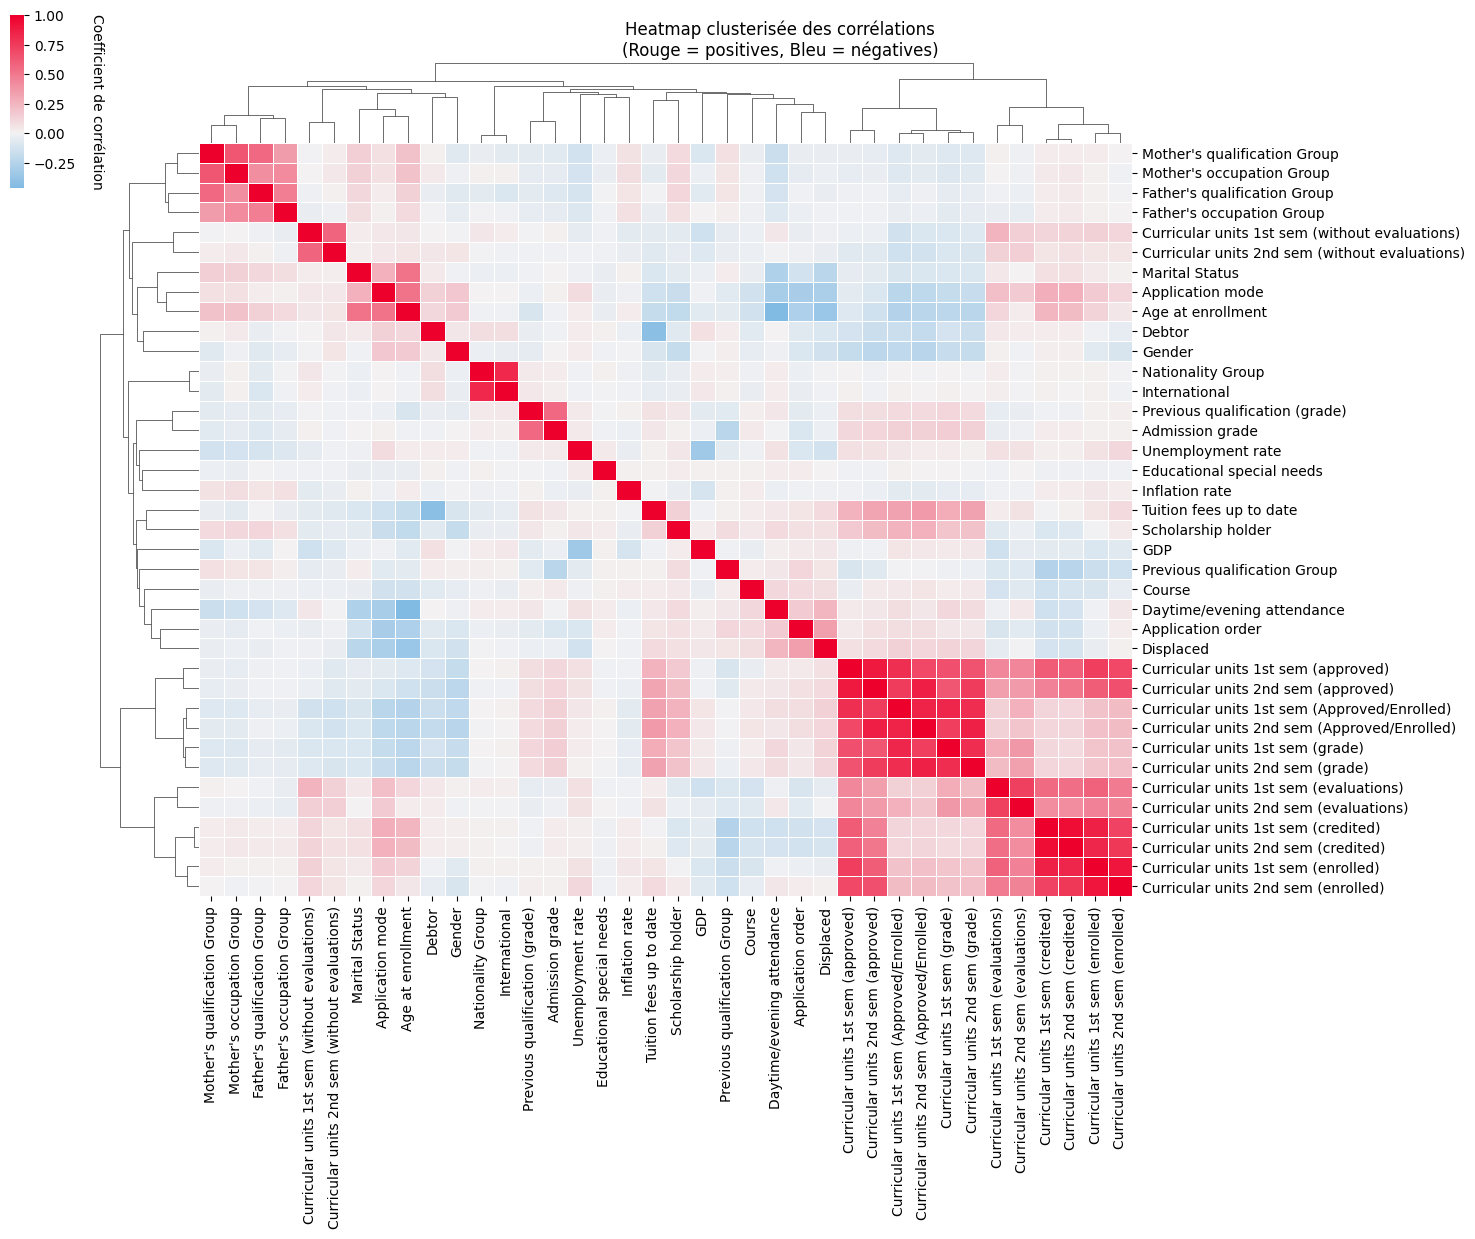

In [7]:
# 📊 MATRICE DE CORRÉLATION COMPLÈTE AVEC HEATMAP CLUSTERISÉE
# ════════════════════════════════════════════════════════════════════════════
# Description: Génération d'une matrice de corrélation complète avec une heatmap clusterisée
# ════════════════════════════════════════════════════════════════════════════

# _________________ 1️⃣  IMPORTATION DES LIBRAIRIES _______________________
# Import des librairies nécessaires

import os
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage
import warnings
warnings.filterwarnings('ignore')

# _________________ 2️⃣  CHARGEMENT DES DONNÉES _______________________
# Recharger le fichier CSV pour s'assurer de partir d'une version propre
df = pd.read_csv(Path.cwd().parent / 'data' / 'data_update.csv', delimiter=';')


# _________________ 3️⃣  GÉNÉRATION DE LA MATRICE DE CORRÉLATION _______________________
# Dossier pour enregistrer les graphiques
graphiques_folder = Path.cwd().parent / 'graphiques'

# Sélection des colonnes numériques uniquement 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[num_cols]

# Calcul de la matrice de corrélation
corr_matrix = df_numeric.corr()

# Extraction des corrélations fortes (|r| ≥ 0.8)
strong_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.8:
            strong_pairs.append((corr_matrix.index[i], corr_matrix.columns[j], val))

# _________________ 4️⃣   AFFICHAGE DES PAIRES FORTEMENT CORRÉLÉES _______________________
# Affichage des paires fortement corrélées dans la console
print("Corrélations fortes (|r| ≥ 0.8) :")
for var1, var2, val in strong_pairs:
    sign = "🔴" if val > 0 else "🔵"  # Rouge si positive, bleu sinon
    print(f"{sign} {var1} ↔ {var2} : {val:.4f}")


# _________________ 5️⃣  GÉNÉRATION DE LA HEATMAP CLUSTERISÉE _______________________
# Création de la palette rouge-blanc-bleu pour heatmap
cmap = sns.diverging_palette(250, 10, s=100, l=50, as_cmap=True)

# Calcul du clustering hiérarchique pour ordonner les variables
link_rows = linkage(corr_matrix, method='average')
link_cols = linkage(corr_matrix.T, method='average')

# Génération et affichage de la heatmap clusterisée complète
g = sns.clustermap(
    corr_matrix,
    row_linkage=link_rows,
    col_linkage=link_cols,
    cmap=cmap,
    center=0,
    linewidths=0.5,
    figsize=(14, 12),
    cbar_kws={'label': 'Coefficient de corrélation'},
    dendrogram_ratio=(0.1, 0.1),
)

# Récupérer la position actuelle de la colorbar (BBox)
pos = g.cax.get_position()

# Déplacer la colorbar horizontalement (x0, x1) ou verticalement (y0, y1)
new_pos = [pos.x0 - 0.07, pos.y0 + 0.08, pos.width, pos.height]

# Appliquer la nouvelle position
g.cax.set_position(new_pos)

# Modifier la taille de la police du label de la colorbar
g.cax.set_ylabel('Coefficient de corrélation', fontsize=10, rotation=270, labelpad=20)

# Modifier la taille et le ratio de la colorbar (l'axe lui-même)
pos = g.cax.get_position()
g.cax.set_position([pos.x0, pos.y0, pos.width * 0.2, pos.height * 0.8])  # Multiplier taille

plt.suptitle('Heatmap clusterisée des corrélations\n(Rouge = positives, Bleu = négatives)', y=1.02)

# _________________ 6️⃣  ENREGISTREMENT DE LA FIGURE _______________________
# Enregistrement de la figure
filename = os.path.join(graphiques_folder, "matrice_correlation.png")
g.savefig(filename)

# _________________ 7️⃣  AFFICHAGE DE LA FIGURE _______________________
# Affichage de la figure
plt.show()


📊 RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS

🌳 ENTRAÎNEMENT RANDOM FOREST
✅ Entraînement terminé

📈 ÉVALUATION

✅ Accuracy:
  Train: 97.05%
  Test: 92.15%

📋 Classification Report (Test set):
              precision    recall  f1-score   support

     Dropout       0.94      0.85      0.89       268
    Graduate       0.91      0.96      0.94       420

    accuracy                           0.92       688
   macro avg       0.93      0.91      0.92       688
weighted avg       0.92      0.92      0.92       688


⭐ FEATURE IMPORTANCE

Top 20 features les plus importantes:
Curricular units 2nd sem (Approved/Enrolled)    0.228934
Curricular units 2nd sem (approved)             0.147085
Curricular units 1st sem (Approved/Enrolled)    0.114288
Curricular units 2nd sem (grade)                0.102344
Curricular units 1st sem (approved)             0.092535
Tuition fees up to date                         0.049284
Curricular units 1st sem (grade)                0.043569
Curricular units 2n

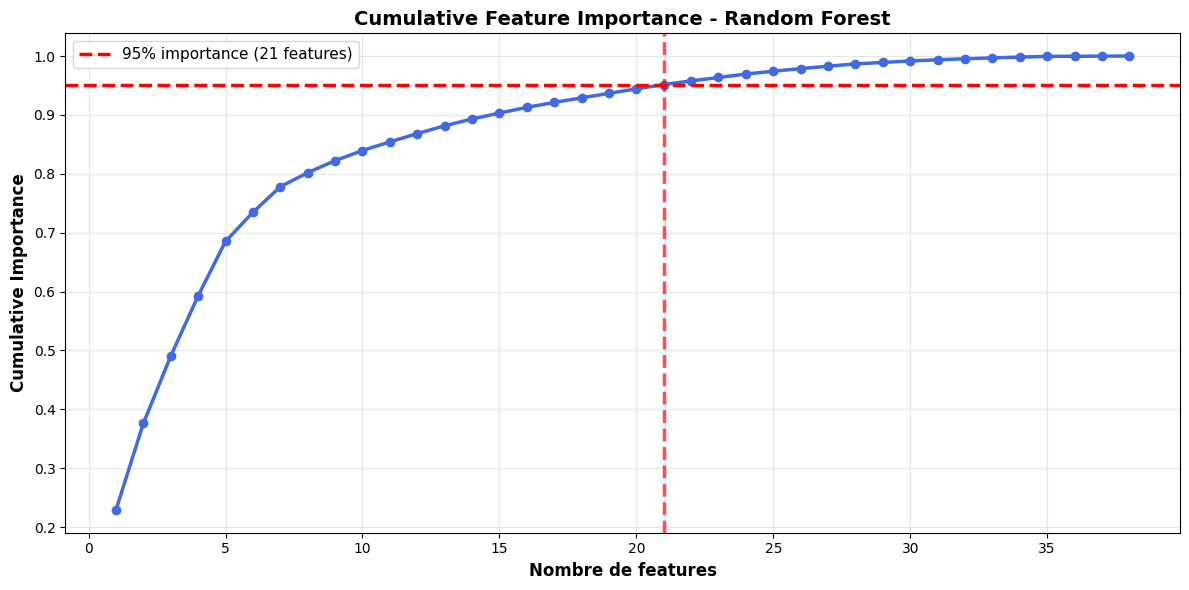

✅ Figure 2 sauvegardée : random_forest_top_features_95.png


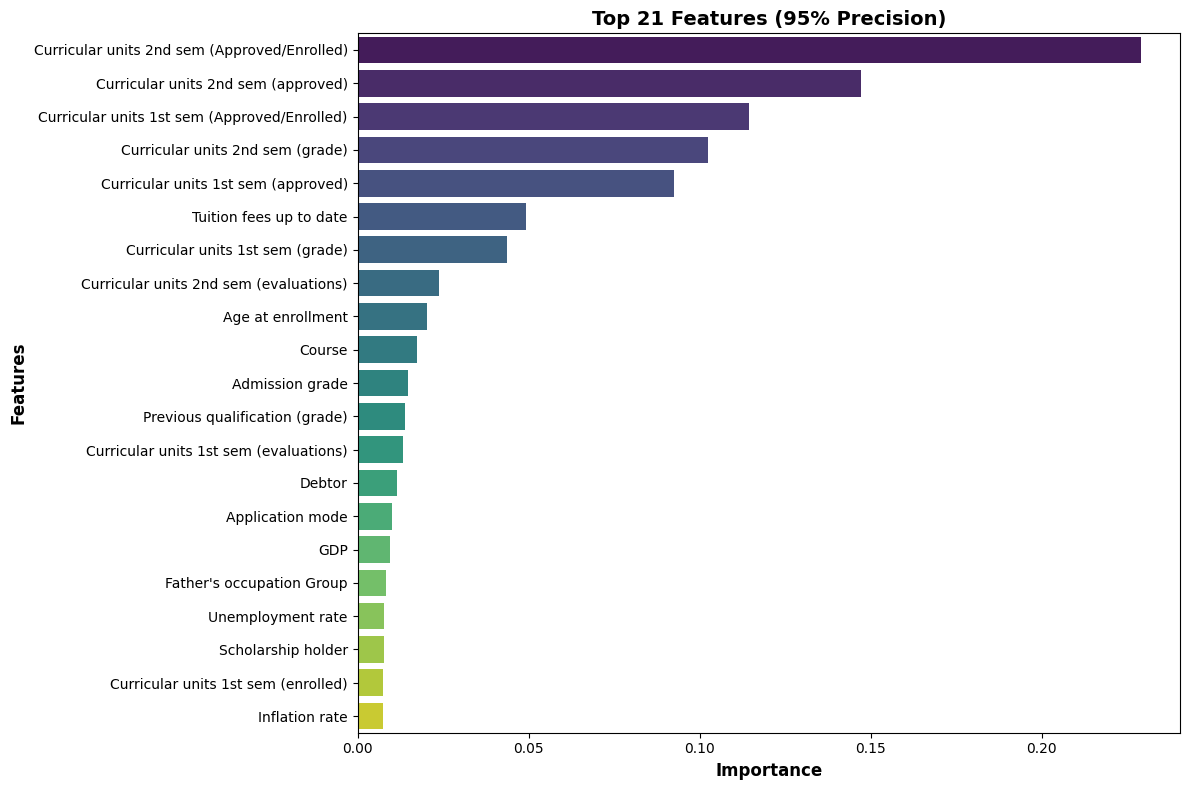


📊 Génération du graphique complet...
✅ Figure 3 sauvegardée : random_forest_all_features.png


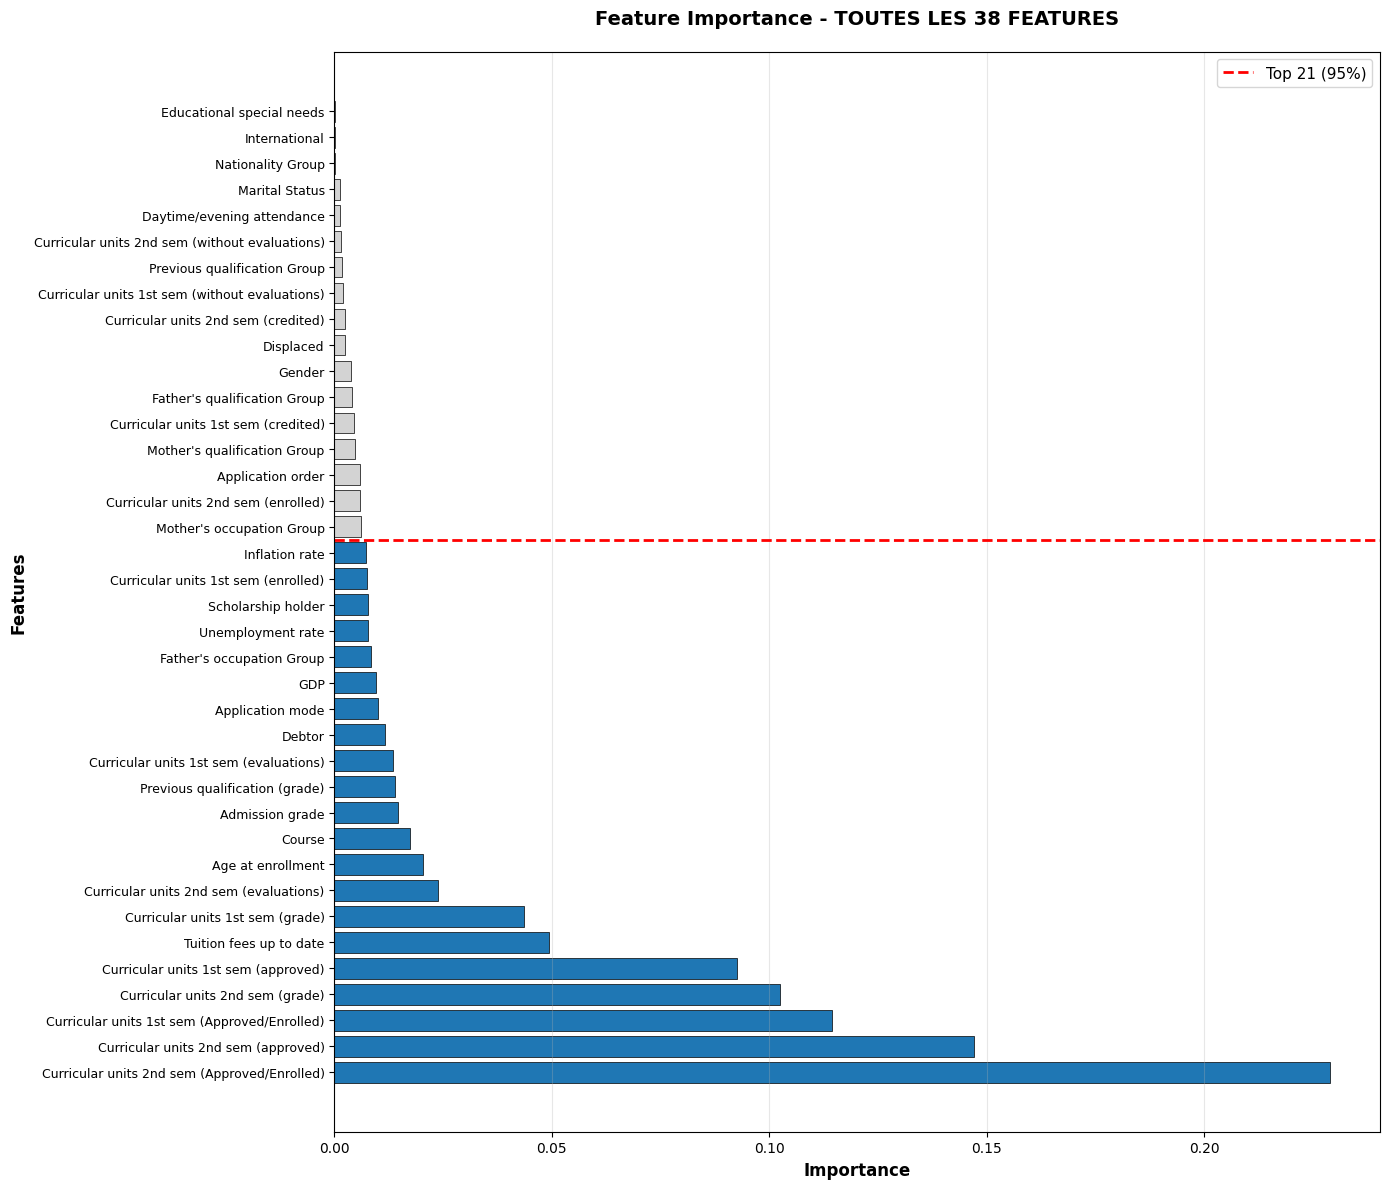


🎯 TOP 21 FEATURES (95% PRECISION)

✅ Ces 21 features représentent 95% de l'importance:

   1. Curricular units 2nd sem (Approved/Enrolled)  : 0.2289
   2. Curricular units 2nd sem (approved)           : 0.1471
   3. Curricular units 1st sem (Approved/Enrolled)  : 0.1143
   4. Curricular units 2nd sem (grade)              : 0.1023
   5. Curricular units 1st sem (approved)           : 0.0925
   6. Tuition fees up to date                       : 0.0493
   7. Curricular units 1st sem (grade)              : 0.0436
   8. Curricular units 2nd sem (evaluations)        : 0.0238
   9. Age at enrollment                             : 0.0204
  10. Course                                        : 0.0173
  11. Admission grade                               : 0.0147
  12. Previous qualification (grade)                : 0.0140
  13. Curricular units 1st sem (evaluations)        : 0.0134
  14. Debtor                                        : 0.0115
  15. Application mode                              : 0.0

'\nMODIFIER LE SEUIL :\n  n_features_95 = (cumulative_importance <= 0.95).sum() + 1\n  Remplacer 0.95 par 0.90 (90%) ou 0.99 (99%)\n\nCHANGER LES COULEURS :\n  Figure 1: color=\'royalblue\' → \'green\', \'purple\', etc.\n  Figure 2: palette="viridis" → "coolwarm", "plasma", "mako"\n  Figure 3: \'#1f77b4\' (bleu), \'#d3d3d3\' (gris) → codes hex personnalisés\n\nAJUSTER TAILLES GRAPHIQUES :\n  figsize=(largeur, hauteur) en pouces\n  Figure 3: fig_height = max(12, len(...) * 0.2) → modifier 0.2\n\nRÉSOLUTION IMAGES :\n  dpi=300 (impression) → dpi=150 (web) ou dpi=600 (haute qualité)\n\nTOP N FEATURES :\n  feature_importances.head(20) → remplacer 20 par le nombre voulu\n\nFORMAT DÉCIMALES :\n  .6f = 6 décimales → .4f ou .2f\n  .2% = 2 décimales % → .1% ou .3%\n'

In [12]:
# 📊 RANDOM FOREST - FEATURE IMPORTANCE & SÉLECTION (95%)
# ════════════════════════════════════════════════════════════════════════════
# Description: Analyse complète des features avec Random Forest
# - Affichage console de TOUTES les features
# - 3 graphiques : cumulative, top 95%, toutes les features
# Auteur: [Ton nom]
# Date: 2025-11-21
# ════════════════════════════════════════════════════════════════════════════


# ═══════════════════════════════════════════════════════════════════════════════
# 1️⃣  IMPORTATION DES LIBRAIRIES
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# ═══════════════════════════════════════════════════════════════════════════════
# 2️⃣  CHARGEMENT DES DONNÉES
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("📊 RANDOM FOREST - FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Charger les fichiers train et test
df_train = pd.read_csv(Path.cwd().parent / 'data' / 'data_train.csv', delimiter=';')
df_test = pd.read_csv(Path.cwd().parent / 'data' / 'data_test.csv', delimiter=';')

# Préparation des données
X_train = df_train.drop(columns=['Target'])
y_train = df_train['Target']
X_test = df_test.drop(columns=['Target'])
y_test = df_test['Target']


# ═══════════════════════════════════════════════════════════════════════════════
# 3️⃣  ENTRAÎNEMENT RANDOM FOREST
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🌳 ENTRAÎNEMENT RANDOM FOREST")
print("="*80)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("✅ Entraînement terminé")


# ═══════════════════════════════════════════════════════════════════════════════
# 4️⃣  ÉVALUATION DU MODÈLE
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 ÉVALUATION")
print("="*80)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

train_score = accuracy_score(y_train, y_pred_train)
test_score = accuracy_score(y_test, y_pred_test)

print(f"\n✅ Accuracy:")
print(f"  Train: {train_score:.2%}")
print(f"  Test: {test_score:.2%}")

print(f"\n📋 Classification Report (Test set):")
print(classification_report(y_test, y_pred_test))


# ═══════════════════════════════════════════════════════════════════════════════
# 5️⃣  EXTRACTION DES IMPORTANCES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("⭐ FEATURE IMPORTANCE")
print("="*80)

importances = rf.feature_importances_
feature_names = X_train.columns
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# TOP 20
print(f"\nTop 20 features les plus importantes:")
print(feature_importances.head(20).to_string())


# ═══════════════════════════════════════════════════════════════════════════════
# 6️⃣  AFFICHAGE COMPLET DE TOUTES LES FEATURES (CONSOLE)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print(f"📊 TOUTES LES {len(feature_importances)} FEATURES - IMPORTANCE COMPLÈTE")
print("="*80)

print("\n" + "-"*95)
print(f"{'Rang':<6} {'Feature':<50} {'Importance':<15} {'Cumulative %':<15}")
print("-"*95)

for i, (feat, importance) in enumerate(feature_importances.items(), 1):
    cumulative_pct = feature_importances.head(i).sum() * 100
    print(f"{i:<6} {feat:<50} {importance:<15.6f} {cumulative_pct:<15.2f}%")

print("-"*95)


# ═══════════════════════════════════════════════════════════════════════════════
# 7️⃣  CALCUL DU SEUIL 95%
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 CUMULATIVE IMPORTANCE (95%)")
print("="*80)

cumulative_importance = feature_importances.cumsum()
n_features_95 = (cumulative_importance <= 0.95).sum() + 1

print(f"\n✅ Features nécessaires pour 95% importance: {n_features_95}")
reduction_pct = (1 - n_features_95/len(feature_importances)) * 100
print(f"  (soit une réduction de {reduction_pct:.1f}%)")


# ═══════════════════════════════════════════════════════════════════════════════
# 8️⃣  GÉNÉRATION DES 3 GRAPHIQUES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("="*80)


# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 1 : Cumulative Importance
# ──────────────────────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_importance)+1), cumulative_importance.values, 
         'o-', lw=2.5, markersize=6, color='royalblue')
plt.axhline(y=0.95, color='red', ls='--', lw=2.5, 
            label=f'95% importance ({n_features_95} features)')
plt.axvline(x=n_features_95, color='red', ls='--', lw=2.5, alpha=0.7)
plt.xlabel("Nombre de features", fontsize=12, fontweight='bold')
plt.ylabel("Cumulative Importance", fontsize=12, fontweight='bold')
plt.title('Cumulative Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(graphiques_folder / 'random_forest_cumulative_95.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 1 sauvegardée : random_forest_cumulative_95.png")
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 2 : Top N Features (95%)
# ──────────────────────────────────────────────────────────────────────────────

top_95_features = feature_importances.head(n_features_95)

plt.figure(figsize=(12, max(8, n_features_95 * 0.25)))
sns.barplot(x=top_95_features.values, y=top_95_features.index, palette="viridis")
plt.title(f'Top {n_features_95} Features (95% Precision)', fontsize=14, fontweight='bold')
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(graphiques_folder / 'random_forest_top_features_95.png', dpi=300, bbox_inches='tight')
print("✅ Figure 2 sauvegardée : random_forest_top_features_95.png")
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# FIGURE 3 : TOUTES LES FEATURES
# ──────────────────────────────────────────────────────────────────────────────

print("\n📊 Génération du graphique complet...")

fig_height = max(12, len(feature_importances) * 0.2)
plt.figure(figsize=(14, fig_height))

# Couleurs : bleu pour top 95%, gris pour le reste
colors = ['#1f77b4' if i < n_features_95 else '#d3d3d3' 
          for i in range(len(feature_importances))]

plt.barh(y=range(len(feature_importances)), 
         width=feature_importances.values,
         color=colors, edgecolor='black', linewidth=0.5)

plt.yticks(range(len(feature_importances)), feature_importances.index, fontsize=9)
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Feature Importance - TOUTES LES {len(feature_importances)} FEATURES', 
          fontsize=14, fontweight='bold', pad=20)

# Ligne de séparation à 95%
if n_features_95 < len(feature_importances):
    plt.axhline(y=n_features_95 - 0.5, color='red', linestyle='--', 
                linewidth=2, label=f'Top {n_features_95} (95%)')
    plt.legend(fontsize=11)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(graphiques_folder / 'random_forest_all_features.png', dpi=300, bbox_inches='tight')
print("✅ Figure 3 sauvegardée : random_forest_all_features.png")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# 9️⃣  RÉSUMÉ FINAL
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print(f"🎯 TOP {n_features_95} FEATURES (95% PRECISION)")
print("="*80)

print(f"\n✅ Ces {n_features_95} features représentent 95% de l'importance:\n")

for i, (feat, importance) in enumerate(top_95_features.items(), 1):
    print(f"  {i:2d}. {feat:45s} : {importance:.4f}")

print("\n" + "="*80)
print("✅ RANDOM FOREST TERMINÉ")
print("="*80)
print(f"\n📁 Fichiers générés:")
print(f"  • random_forest_cumulative_95.png")
print(f"  • random_forest_top_features_95.png")
print(f"  • random_forest_all_features.png")
print("="*80)


# ═══════════════════════════════════════════════════════════════════════════════
# 💡 NOTES D'ADAPTATION RAPIDE
# ═══════════════════════════════════════════════════════════════════════════════
"""
MODIFIER LE SEUIL :
  n_features_95 = (cumulative_importance <= 0.95).sum() + 1
  Remplacer 0.95 par 0.90 (90%) ou 0.99 (99%)

CHANGER LES COULEURS :
  Figure 1: color='royalblue' → 'green', 'purple', etc.
  Figure 2: palette="viridis" → "coolwarm", "plasma", "mako"
  Figure 3: '#1f77b4' (bleu), '#d3d3d3' (gris) → codes hex personnalisés

AJUSTER TAILLES GRAPHIQUES :
  figsize=(largeur, hauteur) en pouces
  Figure 3: fig_height = max(12, len(...) * 0.2) → modifier 0.2

RÉSOLUTION IMAGES :
  dpi=300 (impression) → dpi=150 (web) ou dpi=600 (haute qualité)

TOP N FEATURES :
  feature_importances.head(20) → remplacer 20 par le nombre voulu

FORMAT DÉCIMALES :
  .6f = 6 décimales → .4f ou .2f
  .2% = 2 décimales % → .1% ou .3%
"""

📊 FAMD

📈 VARIANCE EXPLIQUÉE

PCA (variables continues):
  PC1: 41.42%
  PC2: 11.67%
  PC3: 9.89%
  PC4: 7.59%
  PC5: 7.00%
  Total: 80.09%

📊 GÉNÉRATION DES VISUALISATIONS


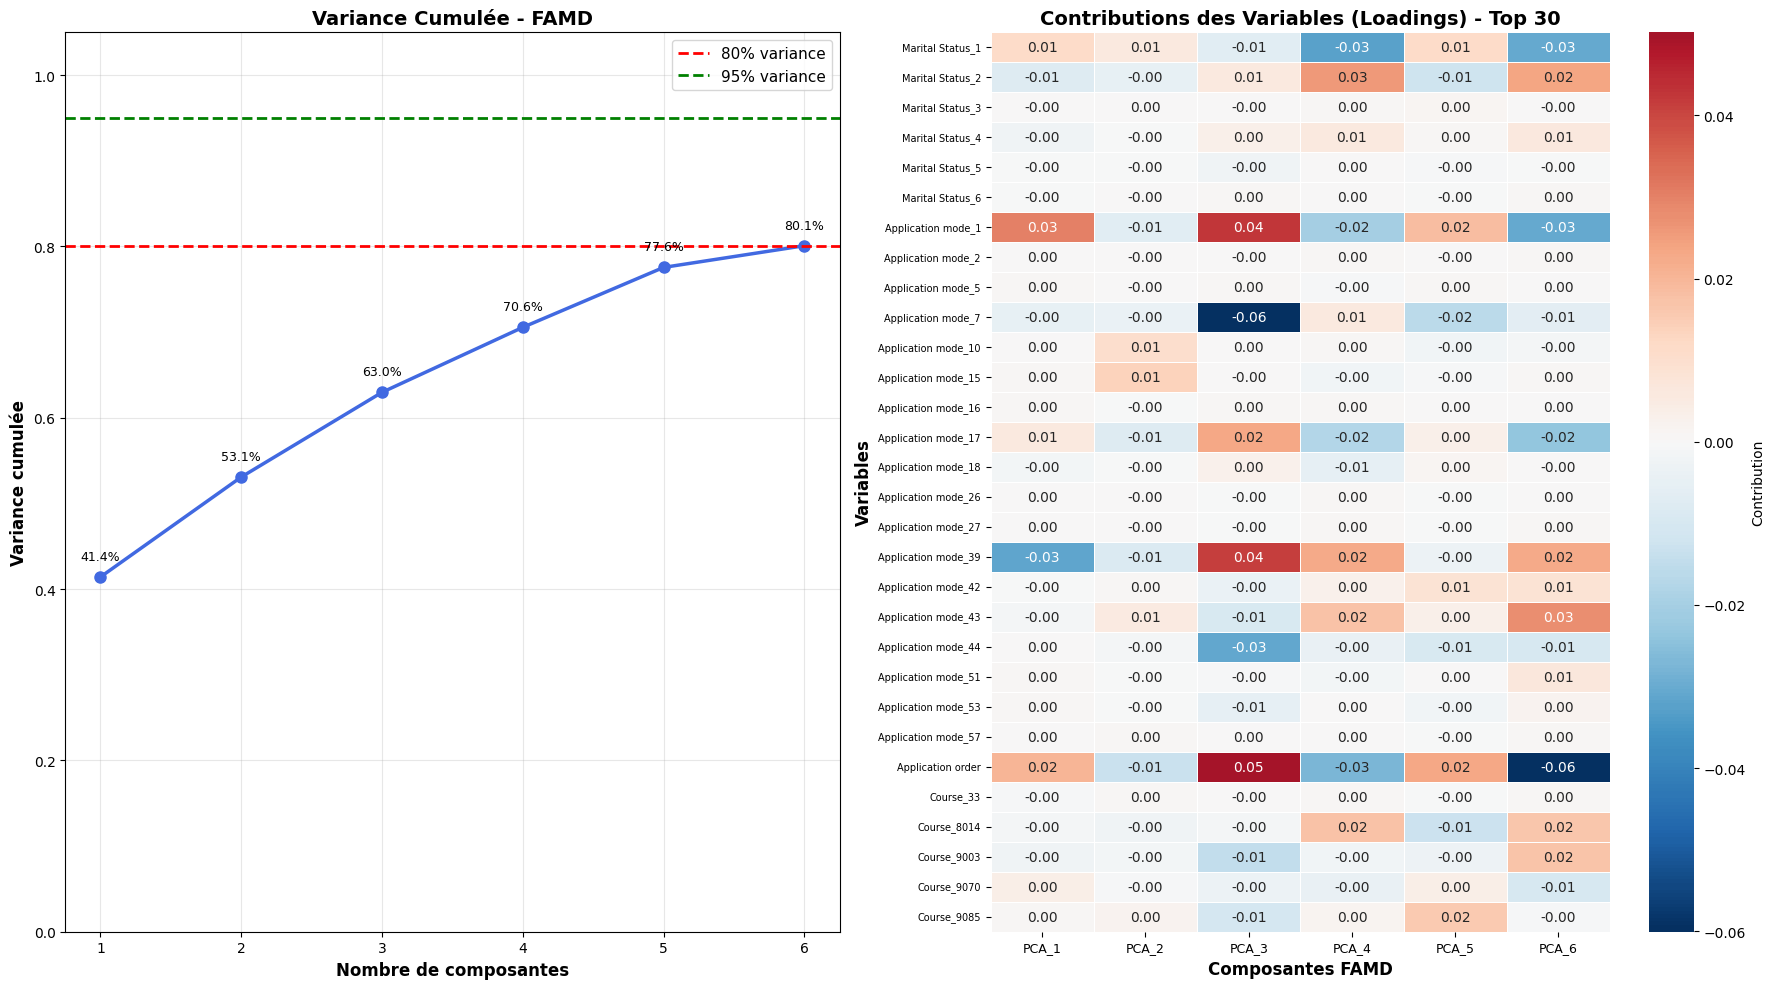


📊 RÉSUMÉ FINAL

✅ Réduction dimensionnelle:
  Original: 83 features
  Après FAMD: 6 composantes
  Réduction: 92.8%

✅ Variance expliquée:
  95% variance: 6 composantes (80.09%)

✅ Données transformées: (2748, 6)

✅ ANALYSE FAMD TERMINÉE


In [5]:
# 📊 FAMD SIMPLE (SANS PREPROCESSING - données déjà traitées)
# ════════════════════════════════════════════════════════════════════════════

# _________________ 1️⃣  IMPORTATION DES LIBRAIRIES _______________________
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

# _________________ 2️⃣  CLASSE MCA SIMPLIFIÉE _______________________
class SimpleMCA:
    """Implémentation simplifiée de MCA (Multiple Correspondence Analysis)"""
    
    def __init__(self, n_components=5, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.pca = None
        
    def fit(self, X):
        """Fit MCA sur données déjà encodées (one-hot)"""
        # Normalise pour MCA
        X_normalized = X / X.sum(axis=1, keepdims=True)
        
        # PCA sur données encodées
        self.pca = PCA(n_components=self.n_components, random_state=self.random_state)
        self.pca.fit(X_normalized)
        
        return self
    
    def transform(self, X):
        """Transforme données"""
        X_normalized = X / X.sum(axis=1, keepdims=True)
        return self.pca.transform(X_normalized)
    
    @property
    def explained_variance_ratio_(self):
        return self.pca.explained_variance_ratio_

# _________________ 3️⃣  CLASSE FAMD SIMPLE (SANS PREPROCESSING) _______________________
class ProperFAMD:
    """
    FAMD SIMPLE (données déjà standardisées/encodées)
    = PCA sur continues + MCA sur catégorielles encodées
    """
    
    def __init__(self, n_components=10, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.pca_continuous = None
        self.mca_categorical = None
        self.continuous_cols = []
        self.categorical_cols = []
        
    def fit(self, X):
        """Fit la FAMD (données déjà traitées)"""
        
        # Identifie colonnes continues (float) vs catégorielles (int/one-hot)
        for col in X.columns:
            if X[col].dtype == 'float64':
                self.continuous_cols.append(col)
            else:
                self.categorical_cols.append(col)
        
        X_continuous = X[self.continuous_cols].copy() if self.continuous_cols else None
        X_categorical = X[self.categorical_cols].copy() if self.categorical_cols else None
        
        # === PCA sur continues ===
        if X_continuous is not None and len(self.continuous_cols) > 0:
            
            n_comp_pca = max(1, int(self.n_components * 0.6))
            self.pca_continuous = PCA(n_components=n_comp_pca, random_state=self.random_state)
            self.pca_continuous.fit(X_continuous)
            
            var_pca = self.pca_continuous.explained_variance_ratio_.sum()
        
        # === MCA sur catégorielles ===
        if X_categorical is not None and len(self.categorical_cols) > 0:
            
            n_comp_mca = max(1, int(self.n_components * 0.4))
            self.mca_categorical = SimpleMCA(n_components=n_comp_mca, random_state=self.random_state)
            self.mca_categorical.fit(X_categorical)
            
            var_mca = self.mca_categorical.explained_variance_ratio_.sum()
        
        return self
    
    def transform(self, X):
        """Transforme données"""
        X_continuous = X[self.continuous_cols].copy() if self.continuous_cols else None
        X_categorical = X[self.categorical_cols].copy() if self.categorical_cols else None
        
        components = []
        
        # Transform PCA
        if self.pca_continuous is not None and X_continuous is not None:
            pca_scores = self.pca_continuous.transform(X_continuous)
            components.append(pca_scores)
        
        # Transform MCA
        if self.mca_categorical is not None and X_categorical is not None:
            mca_scores = self.mca_categorical.transform(X_categorical)
            components.append(mca_scores)
        
        # Combine
        if components:
            X_combined = np.hstack(components)
        else:
            X_combined = X.values
        
        # Noms des colonnes
        col_names = []
        if self.pca_continuous is not None:
            col_names.extend([f'PCA_{i+1}' for i in range(self.pca_continuous.n_components_)])
        if self.mca_categorical is not None:
            col_names.extend([f'MCA_{i+1}' for i in range(self.mca_categorical.n_components)])
        
        return pd.DataFrame(X_combined, columns=col_names)
    
    def fit_transform(self, X):
        """Fit et transform"""
        self.fit(X)
        return self.transform(X)
    
    def get_loadings(self):
        """Récupère la matrice des loadings"""
        loadings_list = []
        variable_names = []
        
        if self.pca_continuous is not None:
            loadings_pca = self.pca_continuous.components_.T
            loadings_list.append(loadings_pca)
            variable_names.extend(self.continuous_cols)
        
        if self.mca_categorical is not None:
            loadings_mca = self.mca_categorical.pca.components_.T
            n_cat_vars = len(self.categorical_cols)
            loadings_mca_simplified = loadings_mca[:n_cat_vars, :]
            loadings_list.append(loadings_mca_simplified)
            variable_names.extend(self.categorical_cols)
        
        if loadings_list:
            all_loadings = np.vstack(loadings_list)
            
            comp_names = []
            if self.pca_continuous is not None:
                comp_names.extend([f'PCA_{i+1}' for i in range(self.pca_continuous.n_components_)])
            if self.mca_categorical is not None:
                comp_names.extend([f'MCA_{i+1}' for i in range(self.mca_categorical.n_components)])
            
            return pd.DataFrame(all_loadings, 
                              index=variable_names, 
                              columns=comp_names)
        return None

# _________________ 4️⃣  SCRIPT PRINCIPAL _______________________

print("="*80)
print("📊 FAMD")
print("="*80)

# Definition des chemins d'accès
data_folder = Path.cwd().parent / 'data'
graphique_folder = Path.cwd().parent / 'graphiques'

# Charger les données déjà standardisées/encodées
df = pd.read_csv(data_folder / 'data_train_encoded.csv', delimiter=';')  # ← À adapter au nom de ton fichier

# Séparer features et target
X = df.drop('Target', axis=1)
y = df['Target']

# ════════════════════════════════════════════════════════════════════════════
# APPLICATION FAMD
# ════════════════════════════════════════════════════════════════════════════

famd = ProperFAMD(n_components=10, random_state=42)
X_famd = famd.fit_transform(X)

# ════════════════════════════════════════════════════════════════════════════
# VARIANCE EXPLIQUÉE
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 VARIANCE EXPLIQUÉE")
print("="*80)

var_explained = []

if famd.pca_continuous:
    var_pca = famd.pca_continuous.explained_variance_ratio_
    var_explained.extend(var_pca)
    print(f"\nPCA (variables continues):")
    for i in range(min(5, len(var_pca))):
        print(f"  PC{i+1}: {var_pca[i]:.2%}")
    print(f"  Total: {var_pca.sum():.2%}")

if famd.mca_categorical:
    var_mca = famd.mca_categorical.explained_variance_ratio_
    var_explained.extend(var_mca)
    print(f"\nMCA (variables catégorielles):")
    for i in range(min(5, len(var_mca))):
        print(f"  MC{i+1}: {var_mca[i]:.2%}")
    print(f"  Total: {var_mca.sum():.2%}")

# ════════════════════════════════════════════════════════════════════════════
# VISUALISATIONS (2 FIGURES SÉPARÉES)
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 GÉNÉRATION DES VISUALISATIONS")
print("="*80)

cumsum = np.cumsum(var_explained)

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 : VARIANCE CUMULÉE
# ════════════════════════════════════════════════════════════════════════════

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(var_explained)+1), cumsum, 'o-', lw=2.5, color='royalblue', markersize=10)
plt.axhline(y=0.80, color='red', ls='--', lw=2, label='80% variance')
plt.axhline(y=0.95, color='green', ls='--', lw=2, label='95% variance')
plt.xlabel("Nombre de composantes", fontsize=14, fontweight='bold')
plt.ylabel("Variance cumulée", fontsize=14, fontweight='bold')
plt.title("Variance Cumulée - FAMD", fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])

# Afficher les valeurs sur le graphique
for i, cum in enumerate(cumsum):
    plt.text(i+1, cum+0.02, f'{cum:.1%}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('famd_variance_cumulee.png', dpi=300, bbox_inches='tight')
print("\n✅ Figure 1 sauvegardée : famd_variance_cumulee.png")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 : HEATMAP DES LOADINGS
# ════════════════════════════════════════════════════════════════════════════

loadings_df = famd.get_loadings()

if loadings_df is not None:
    # Nombre de variables à afficher
    n_vars_to_show = min(len(loadings_df), 50)  # Top 50 ou toutes si moins
    
    # Trier par importance moyenne (optionnel)
    loadings_importance = loadings_df.abs().mean(axis=1).sort_values(ascending=False)
    loadings_display = loadings_df.loc[loadings_importance.head(n_vars_to_show).index, :]
    
    # Créer la figure
    plt.figure(figsize=(14, max(10, n_vars_to_show * 0.3)))  # Hauteur adaptative
    
    sns.heatmap(loadings_display, 
                annot=True, 
                fmt='.2f',
                cmap='RdBu_r', 
                center=0, 
                cbar_kws={'label': 'Contribution'},
                linewidths=0.5,
                annot_kws={'size': 8})
    
    plt.title(f"Contributions des Variables (Loadings) - Top {n_vars_to_show}", 
              fontsize=16, fontweight='bold')
    plt.xlabel("Composantes FAMD", fontsize=14, fontweight='bold')
    plt.ylabel("Variables", fontsize=14, fontweight='bold')
    plt.tick_params(axis='y', labelsize=9)
    plt.tick_params(axis='x', labelsize=10)
    
    plt.tight_layout()
    plt.savefig(graphiques_folder / 'famd_loadings_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()


# ════════════════════════════════════════════════════════════════════════════
# RÉSUMÉ FINAL
# ════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 RÉSUMÉ FINAL")
print("="*80)

n_95 = np.where(cumsum >= 0.95)[0][0] + 1 if any(cumsum >= 0.95) else len(cumsum)

print(f"\n✅ Réduction dimensionnelle:")
print(f"  Original: {X.shape[1]} features")
print(f"  Après FAMD: {X_famd.shape[1]} composantes")
print(f"  Réduction: {(1 - X_famd.shape[1]/X.shape[1])*100:.1f}%")

print(f"\n✅ Variance expliquée:")
print(f"  95% variance: {n_95} composantes ({cumsum[n_95-1]:.2%})")

print(f"\n✅ Données transformées: {X_famd.shape}")

print("\n" + "="*80)
print("✅ ANALYSE FAMD TERMINÉE")
print("="*80)
